In [1]:
## --- Bootstrap: Load shared environment setup ---

import os
from google.colab import drive

# Mount Drive only if not already mounted
if not os.path.ismount("/content/drive"):
    drive.mount('/content/drive')

# Path to your setup notebook
SETUP_NOTEBOOK = "/content/drive/MyDrive/ai_projects/setup_environment.ipynb"

# Run the setup notebook
%run $SETUP_NOTEBOOK

print("Environment initialized and ready.")


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 2.7 MB/s eta 0:00:00
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'libgraphviz-dev' instead of 'graphviz-dev'
graphviz is already the newest version (2.42.2-6ubuntu0.1).
The following packages were automatically installed and are no longer required:
  libbz2-dev libpkgconf3 libreadline-dev
Use 'apt autoremove' to remove them.
The following additional packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgtk2.0-0
  libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk librsvg2-common
  libxcomposite1 libxdot4
Suggested packages:
  gvfs
The following packages will be REMOVED:
  pkgconf r-base-dev
The following NEW packages wil

In [2]:
from typing import TypedDict, Annotated,Sequence
from langchain_core.messages import BaseMessage
from langchain_core.messages import ToolMessage
from langchain_core.messages import SystemMessage
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode

In [3]:
llm = ChatOpenAI(model="gpt-4o")

In [4]:
class AgentState(TypedDict):
  messages: Annotated[Sequence[BaseMessage], add_messages]

In [5]:
@tool
def add(a: int, b: int) -> int:
  '''
  Addition tool that adds two numbers together
  '''
  return a + b
tools = [add]


In [6]:
@tool
def subtract(a: int, b: int):
  '''
  Subtraction tool that subtracts two numbers
  '''
  return a - b
tools.append(subtract)

In [7]:
@tool
def multiply(a: int, b: int):
  '''
  Multiplication tool that multiplies two numbers
  '''
  return a * b
tools.append(multiply)

In [8]:
@tool
def divide(a: int, b: int):
  '''
  Division tool that divides two numbers
  '''
  if b == 0:
    raise ValueError("Cannot divide by zero")
  return a / b
tools.append(divide)


In [9]:
model = ChatOpenAI(model = "gpt-4o").bind_tools(tools)

In [10]:
def model_call(state: AgentState) -> AgentState:
  system_prompt = SystemMessage(content =
                                "You are my AI assistant, please answer my query to the best of your ability, and call me Steve")
  response = model.invoke([system_prompt] + state["messages"])
  return {"messages":[response]}

In [11]:
def should_continue(state: AgentState):
  messages = state["messages"]
  last_message = messages[-1]
  if not last_message.tool_calls:
    return "end"
  else:
    return "continue"

In [12]:
graph = StateGraph(AgentState)
graph.add_node("our_agent", model_call)

In [13]:
tool_node = ToolNode(tools = tools)
graph.add_node("tools", tool_node)
graph.set_entry_point("our_agent")

In [14]:
graph.add_conditional_edges(
    "our_agent", should_continue,
  {
        "continue": "tools",
        "end": END
  }
)

In [15]:
graph.add_edge("tools", "our_agent")
app = graph.compile()

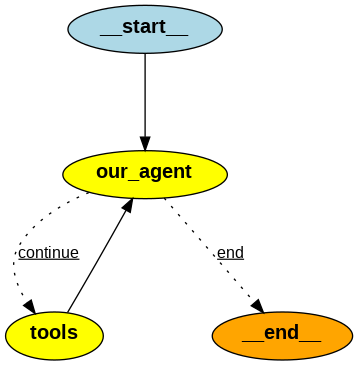

In [16]:
from IPython.display import Image, display

# Generate a visualization of the workflow graph
display(Image(app.get_graph().draw_png()))


In [17]:
def print_stream(stream):
  for s in stream:
    message = s["messages"][-1]
    if isinstance(message, tuple):
      print(message)
    else:
      message.pretty_print()

In [19]:
inputs = {"messages": [("user", "Add 40 + 12.  and multiply the result by 6 then divde that by 2 and oh tell me something interesting")]}
print_stream(app.stream(inputs, stream_mode = "values"))

================================ Human Message =================================

Add 40 + 12.  and multiply the result by 6 then divde that by 2 and oh tell me something interesting
================================== Ai Message ==================================
Tool Calls:
  add (call_wMcnzlcoKtsRO1LlmiYEZLQ3)
 Call ID: call_wMcnzlcoKtsRO1LlmiYEZLQ3
  Args:
    a: 40
    b: 12
  multiply (call_s0hn9fJPAJ2Kq6lJv9iHCAkN)
 Call ID: call_s0hn9fJPAJ2Kq6lJv9iHCAkN
  Args:
    a: 52
    b: 6
  divide (call_9orORdVvxhjpMZHM20rDzPIG)
 Call ID: call_9orORdVvxhjpMZHM20rDzPIG
  Args:
    a: 312
    b: 2
================================= Tool Message =================================
Name: divide

156.0
================================== Ai Message ==================================

The result of adding 40 and 12 is 52. When you multiply that by 6, you get 312. Dividing 312 by 2 gives you 156.

Here's something interesting: Did you know that honey never spoils? Archaeologists have found pots of 